## Introduction

Electrocardiogram (ECG) signals are widely used to monitor heart activity and detect potential abnormalities. Early detection of abnormal heartbeats (arrhythmias) is crucial for preventing serious health issues and improving patient outcomes.

In this project, we aim to build an anomaly detection system using deep learning techniques, specifically an Autoencoder neural network. The model is trained to learn the normal patterns of ECG signals and reconstruct them accurately. When the model encounters abnormal patterns, it produces a higher reconstruction error, which can be used to identify anomalies.

The dataset used in this project is the MIT-BIH Arrhythmia dataset, which contains labeled ECG signals categorized into different heartbeat classes. The project includes data preprocessing, model design, training with regularization techniques, and evaluation using reconstruction error and classification metrics.

This approach demonstrates how deep learning can be applied to real-world healthcare problems, enabling automated and efficient detection of abnormal heart conditions.


In [2]:
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip heartbeat.zip

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
100% 98.8M/98.8M [00:03<00:00, 32.6MB/s]

Archive:  heartbeat.zip
  inflating: mitbih_test.csv         
  inflating: mitbih_train.csv        
  inflating: ptbdb_abnormal.csv      
  inflating: ptbdb_normal.csv        


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import pandas as pd
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

In [4]:
train_df[187].value_counts()

,count
187,
0.0,72471
4.0,6431
2.0,5788
1.0,2223
3.0,641


Important Observation:
The dataset is highly imbalanced
Class 0 has the majority of samples
Other classes (especially 3 and 1) have much fewer samples

In [5]:
train_df.isnull().sum().sum()

np.int64(0)

The result shows there are 82 missing values

In [6]:
train_df = train_df.dropna()

In [7]:
train_df.isnull().sum().sum()

np.int64(0)

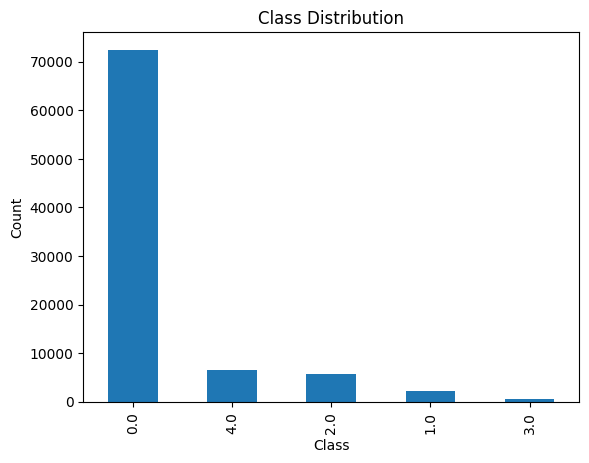

In [8]:
import matplotlib.pyplot as plt

train_df.iloc[:, -1].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

###The class distribution was highly imbalanced, with class 0 dominating the dataset.

###Split features and target

In [9]:
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]

print(X.shape)
print(y.shape)

(87554, 187)
(87554,)


In [47]:
from sklearn.model_selection import train_test_split

X_normal = X[y == 0]

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

###Import StandardScaler

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [46]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

-4.3331411195243765 52.33355774311635
-6.605880615680523e-17 1.0000000000000004


In [26]:
X_test = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

y_test = (y_test_raw != 0).astype(int)

X_test = scaler.transform(X_test)

In [14]:
X.min(), X.max()

(0      0.0
 1      0.0
 2      0.0
 3      0.0
 4      0.0
       ... 
 182    0.0
 183    0.0
 184    0.0
 185    0.0
 186    0.0
 Length: 187, dtype: float64,
 0      1.0
 1      1.0
 2      1.0
 3      1.0
 4      1.0
       ... 
 182    1.0
 183    1.0
 184    1.0
 185    1.0
 186    1.0
 Length: 187, dtype: float64)

###Baseline Autoencoder

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_autoencoder(input_dim):#187
    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)

    # Decoder
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

baseline_model = build_baseline_autoencoder(X_train.shape[1])

In [48]:
history = baseline_model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, X_val)
)

Epoch 1/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 486us/step - loss: 0.0012 - val_loss: 8.2722e-04
Epoch 2/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 485us/step - loss: 7.4745e-04 - val_loss: 6.8118e-04
Epoch 3/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step - loss: 6.5859e-04 - val_loss: 6.1490e-04
Epoch 4/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - loss: 5.9647e-04 - val_loss: 5.7052e-04
Epoch 5/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step - loss: 5.5111e-04 - val_loss: 5.3814e-04
Epoch 6/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - loss: 5.1262e-04 - val_loss: 5.0094e-04
Epoch 7/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step - loss: 4.8798e-04 - val_loss: 4.7434e-04
Epoch 8/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 482us/step - loss: 4.6569e-04 - val_loss: 4.4654e-04
Epoch 9/20
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 1s 479us/step - loss: 4.5009e-04 - val_loss: 4.8647e-04
Epoch 10/20
 884/1812 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - loss: 4.2572e-04

KeyboardInterrupt: 

###Build Regularized Autoencoder

In [54]:
def build_regularized_autoencoder(input_dim):
    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = layers.Dense(32, activation='relu')(x)

    # Decoder
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='linear')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')

    return model

###Early Stopping

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_reg = reg_model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop]
)

print("DONE")

Epoch 1/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - loss: 0.0026 - val_loss: 0.0013
Epoch 2/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - loss: 0.0026 - val_loss: 0.0013
Epoch 3/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step - loss: 0.0026 - val_loss: 0.0013
Epoch 4/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 644us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 5/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 583us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 6/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 7/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 588us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 8/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - loss: 0.0025 - val_loss: 0.0013
Epoch 9/50
906/906 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.0025 - val_loss: 0.0013
DONE


In [56]:
import numpy as np
reconstructions = reg_model.predict(X_train)
mse = np.mean(np.power(X_train - reconstructions, 2), axis=1)

1812/1812 ━━━━━━━━━━━━━━━━━━━━ 0s 201us/step


In [57]:
mse[:10]

,0
20097,0.000442
28366,0.003992
57517,0.000527
65969,0.000633
39481,0.000524
54966,0.000834
33364,0.000477
3077,0.001378
9792,0.001915
68720,0.000891


In [65]:
# train
reconstructions_train = reg_model.predict(X_train)
mse_train = np.mean((X_train - reconstructions_train)**2, axis=1)

# test
reconstructions_test = reg_model.predict(X_test)
mse_test = np.mean((X_test - reconstructions_test)**2, axis=1)

thresholds = [95, 90, 85, 80, 75]

from sklearn.metrics import classification_report

for t in thresholds:
    threshold = np.percentile(mse_train, t)
    preds = mse_test > threshold

    print(f"\nThreshold: {t}%")
    print(classification_report(y_test, preds))

1812/1812 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step

Threshold: 95%
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     18118
           1       0.71      0.63      0.67      3774

    accuracy                           0.89     21892
   macro avg       0.82      0.79      0.80     21892
weighted avg       0.89      0.89      0.89     21892


Threshold: 90%
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     18118
           1       0.60      0.74      0.66      3774

    accuracy                           0.87     21892
   macro avg       0.77      0.82      0.79     21892
weighted avg       0.88      0.87      0.87     21892


Threshold: 85%
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     18118
           1       0.52      0.79      0.63      3774

    accuracy                           0.84   

In [68]:
results = pd.DataFrame({
    "true_label": y_test,
    "mse": mse_test
})

In [70]:
threshold = np.percentile(mse_train, 80)   #train
anomalies = mse_test > threshold           # test

results["anomaly"] = anomalies

results.head()

,true_label,mse,anomaly
0,0,0.000537,False
1,0,0.001692,True
2,0,0.002152,True
3,0,0.000361,False
4,0,0.002408,True


In [71]:
results["true_label"]

,true_label
0,0
1,0
2,0
3,0
4,0
...,...
21887,1
21888,1
21889,1
21890,1


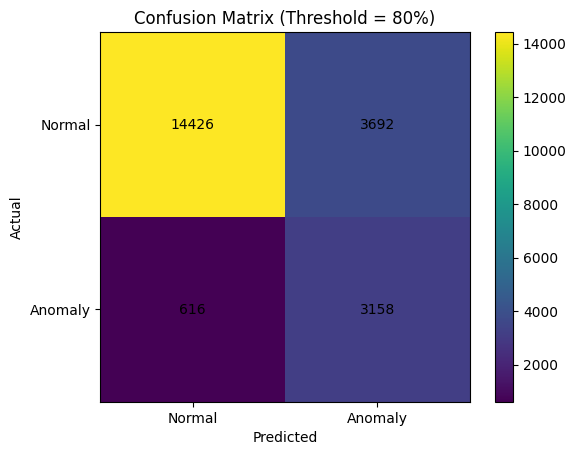

In [72]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, anomalies)

labels = ["Normal", "Anomaly"]

plt.figure()
plt.imshow(cm)

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = 80%)")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()